# Portfolio Optimization using Modern Portfolio Theory

This project optimizes a portfolio of Indian stocks using Efficient Frontier and Sharpe Ratio.

Stocks used:
RELIANCE
TCS
HDFC Bank
Infosys
ITC

Tech Stack:
Python
PyPortfolioOpt
Monte Carlo Simulation
Yahoo Finance API

In [1]:
!pip install yfinance pandas numpy matplotlib pandas_datareader PyPortfolioOpt plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 6.6 MB/s eta 0:00:00


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import datetime

from pypfopt import EfficientFrontier
from pypfopt import expected_returns
from pypfopt import risk_models
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

import plotly.graph_objects as go

plt.style.use("fivethirtyeight")

risk_free_rate = 0.07

In [18]:
assets = ["RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ITC.NS"]

weights = np.array([0.2,0.2,0.2,0.2,0.2])

In [19]:
stockStartDate = "2019-01-01"
today = datetime.today().strftime("%Y-%m-%d")

In [20]:
df = yf.download(assets, start=stockStartDate, end=today)["Close"]

df.head()

/tmp/ipykernel_661/3980452931.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  5 of 5 completed


Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2019-01-01,504.392517,553.448425,201.856064,498.490570,1582.166138
2019-01-02,499.790283,556.777283,200.356613,491.998230,1599.211914
2019-01-03,495.868927,556.860474,199.107071,485.928345,1579.796265
2019-01-04,497.195587,550.119690,200.606552,488.551910,1560.588867
2019-01-07,497.946899,558.982544,201.106354,491.264465,1578.091675


In [21]:
mu = expected_returns.mean_historical_return(df)

S = risk_models.sample_cov(df)

In [22]:
ef = EfficientFrontier(mu,S)

weights = ef.max_sharpe(risk_free_rate=risk_free_rate)

cleaned_weights = ef.clean_weights()

print("Optimal Weights")

print(cleaned_weights)

Optimal Weights
OrderedDict({'HDFCBANK.NS': 0.0, 'INFY.NS': 0.28709, 'ITC.NS': 0.0, 'RELIANCE.NS': 0.71291, 'TCS.NS': 0.0})


In [23]:
expected_return, volatility, sharpe = ef.portfolio_performance(
    risk_free_rate=risk_free_rate
)

print(f"Expected annual return: {expected_return:.2%}")
print(f"Volatility: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")

Expected annual return: 14.57%
Volatility: 23.55%
Sharpe Ratio: 0.32


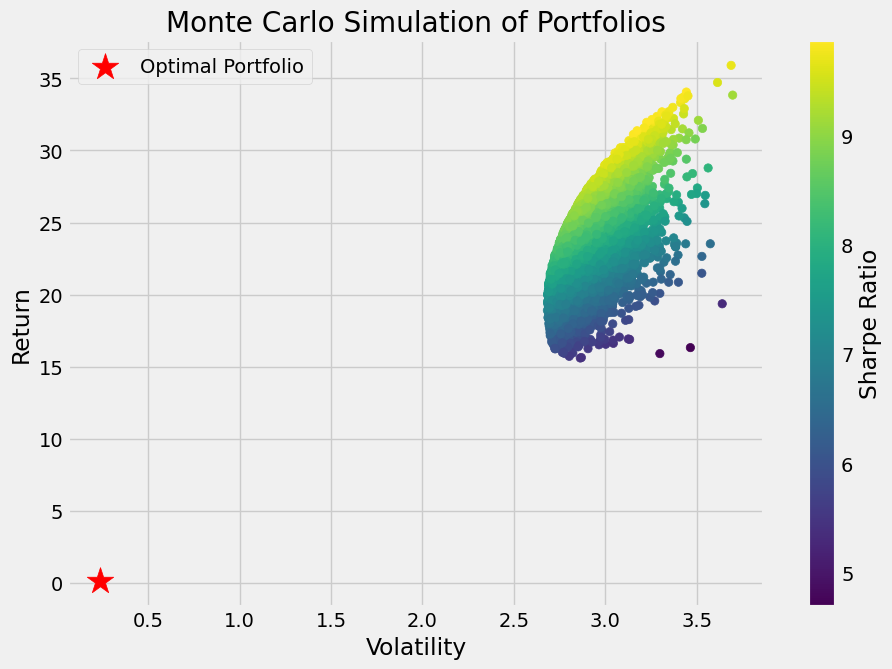

In [24]:
num_portfolios = 10000

returns = []
volatility_list = []
sharpe_list = []

for i in range(num_portfolios):

    w = np.random.random(len(assets))
    w /= np.sum(w)

    port_return = np.sum(mu * w) * 252

    port_vol = np.sqrt(np.dot(w.T,np.dot(S*252,w)))

    sharpe_ratio = (port_return-risk_free_rate)/port_vol

    returns.append(port_return)
    volatility_list.append(port_vol)
    sharpe_list.append(sharpe_ratio)

plt.figure(figsize=(10,7))

plt.scatter(volatility_list,returns,c=sharpe_list,cmap="viridis")

plt.colorbar(label="Sharpe Ratio")

plt.scatter(volatility,expected_return,
            marker="*",color="red",s=400,
            label="Optimal Portfolio")

plt.xlabel("Volatility")
plt.ylabel("Return")

plt.title("Monte Carlo Simulation of Portfolios")

plt.legend()

plt.show()

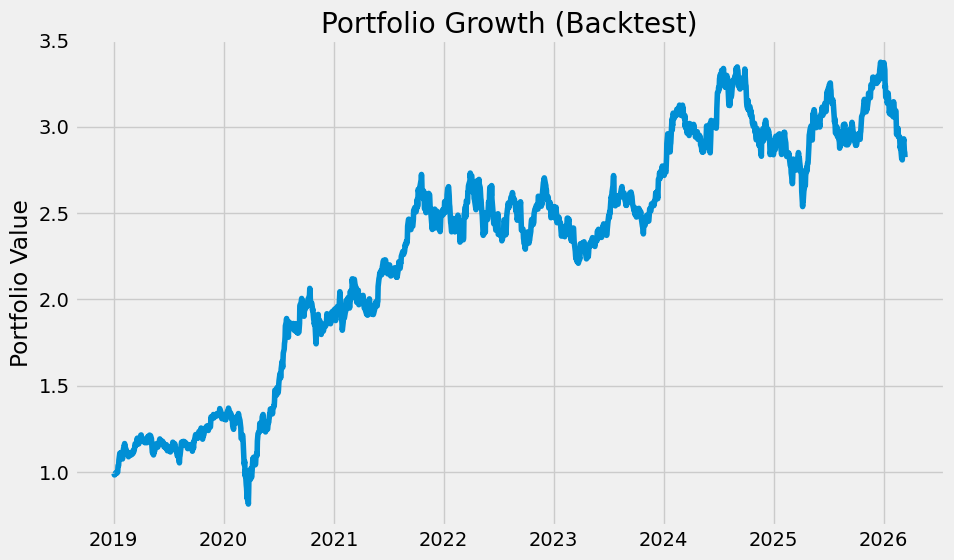

In [25]:
returns = df.pct_change().dropna()

portfolio_returns = returns.dot(list(cleaned_weights.values()))

cumulative_returns = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(10,6))

plt.plot(cumulative_returns)

plt.title("Portfolio Growth (Backtest)")
plt.ylabel("Portfolio Value")

plt.show()

In [26]:
latest_prices = get_latest_prices(df)

da = DiscreteAllocation(
    cleaned_weights,
    latest_prices,
    total_portfolio_value=100000
)

allocation,leftover = da.lp_portfolio()

print("Discrete Allocation")

print(allocation)

print("Funds remaining: ₹{:.2f}".format(leftover))

Discrete Allocation
{'INFY.NS': 23, 'RELIANCE.NS': 51}
Funds remaining: ₹873.40


In [27]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=volatility_list,
        y=returns,
        mode="markers",
        marker=dict(
            color=sharpe_list,
            colorscale="Viridis",
            showscale=True
        ),
        name="Random Portfolios"
    )
)

fig.add_trace(
    go.Scatter(
        x=[volatility],
        y=[expected_return],
        mode="markers",
        marker=dict(size=15,color="red"),
        name="Optimal Portfolio"
    )
)

fig.update_layout(
    title="Efficient Frontier (Interactive)",
    xaxis_title="Volatility",
    yaxis_title="Return"
)

fig.show()

In [28]:
df.to_csv("portfolio_stock_data.csv")

In [30]:
# Download NIFTY50 data
nifty_data = yf.download("^NSEI", start=stockStartDate, end=today)["Close"]

# Convert to Series if dataframe
if isinstance(nifty_data, pd.DataFrame):
    nifty_data = nifty_data.squeeze()

# Calculate returns
nifty_returns = nifty_data.pct_change().dropna()

# Annual metrics
nifty_annual_return = float(nifty_returns.mean() * 252)
nifty_annual_volatility = float(nifty_returns.std() * np.sqrt(252))

# Sharpe ratio
nifty_sharpe = float((nifty_annual_return - risk_free_rate) / nifty_annual_volatility)

print("="*50)
print("PORTFOLIO PERFORMANCE vs NIFTY50")
print("="*50)

print("\nOPTIMAL PORTFOLIO")
print(f"Return: {expected_return:.2%}")
print(f"Volatility: {volatility:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")

print("\nNIFTY50 BENCHMARK")
print(f"Return: {nifty_annual_return:.2%}")
print(f"Volatility: {nifty_annual_volatility:.2%}")
print(f"Sharpe Ratio: {nifty_sharpe:.2f}")

print("\nOUTPERFORMANCE")
print(f"Return Difference: {(expected_return-nifty_annual_return)*100:.2f}%")
print(f"Sharpe Difference: {(sharpe-nifty_sharpe):.2f}")

/tmp/ipykernel_661/3791709541.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

PORTFOLIO PERFORMANCE vs NIFTY50

OPTIMAL PORTFOLIO
Return: 14.57%
Volatility: 23.55%
Sharpe Ratio: 0.32

NIFTY50 BENCHMARK
Return: 12.38%
Volatility: 17.50%
Sharpe Ratio: 0.31

OUTPERFORMANCE
Return Difference: 2.19%
Sharpe Difference: 0.01


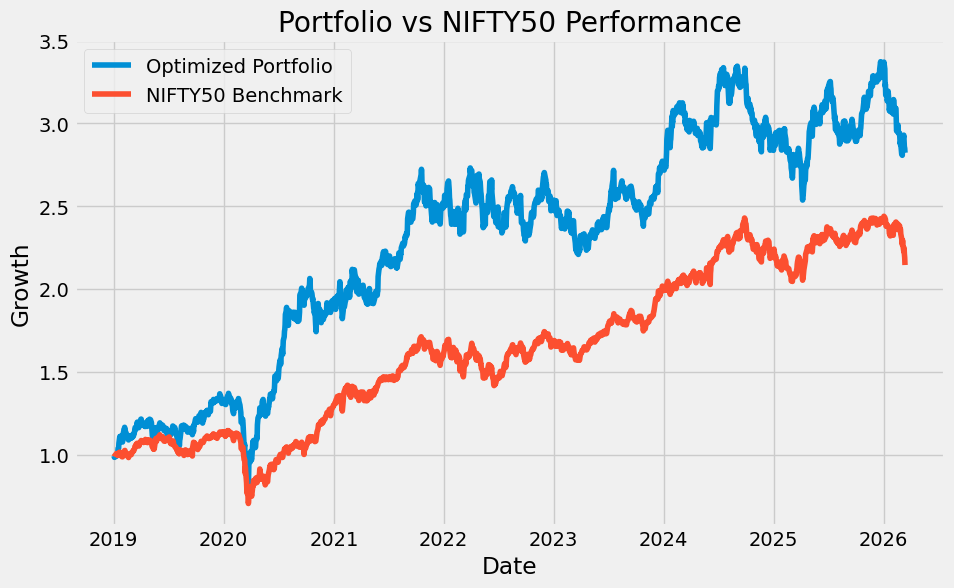

In [31]:
# Portfolio cumulative returns
portfolio_returns = df.pct_change().dropna().dot(list(cleaned_weights.values()))
portfolio_growth = (1 + portfolio_returns).cumprod()

# NIFTY cumulative returns
nifty_growth = (1 + nifty_returns).cumprod()

plt.figure(figsize=(10,6))

plt.plot(portfolio_growth,label="Optimized Portfolio")
plt.plot(nifty_growth,label="NIFTY50 Benchmark")

plt.title("Portfolio vs NIFTY50 Performance")
plt.xlabel("Date")
plt.ylabel("Growth")

plt.legend()
plt.show()

In [32]:
import plotly.graph_objects as go

# Create interactive portfolio performance chart
fig = go.Figure()

# Portfolio growth
portfolio_returns = df.pct_change().dropna().dot(list(cleaned_weights.values()))
portfolio_growth = (1 + portfolio_returns).cumprod()

# NIFTY growth
nifty_growth = (1 + nifty_returns).cumprod()

fig.add_trace(
    go.Scatter(
        x=portfolio_growth.index,
        y=portfolio_growth,
        mode="lines",
        name="Optimized Portfolio"
    )
)

fig.add_trace(
    go.Scatter(
        x=nifty_growth.index,
        y=nifty_growth,
        mode="lines",
        name="NIFTY50 Benchmark"
    )
)

fig.update_layout(
    title="Portfolio vs NIFTY50 Performance (Interactive)",
    xaxis_title="Date",
    yaxis_title="Growth",
    hovermode="x unified"
)

fig.show()